In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import streamlit as st
from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PROJECT_ROOT = Path.cwd().parent

DB_PATH = PROJECT_ROOT / "data" / "sales_intelligence.db"
DASHBOARD_DIR = PROJECT_ROOT / "dashboard"
APP_PATH = DASHBOARD_DIR / "app.py"

DASHBOARD_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Database:", DB_PATH)
print("Dashboard folder:", DASHBOARD_DIR)
print("App path:", APP_PATH)

Project root: c:\Users\User\OneDrive\Pictures\Desktop\Shanmukha\Projects\Sales-Intelligence-Analytics
Database: c:\Users\User\OneDrive\Pictures\Desktop\Shanmukha\Projects\Sales-Intelligence-Analytics\data\sales_intelligence.db
Dashboard folder: c:\Users\User\OneDrive\Pictures\Desktop\Shanmukha\Projects\Sales-Intelligence-Analytics\dashboard
App path: c:\Users\User\OneDrive\Pictures\Desktop\Shanmukha\Projects\Sales-Intelligence-Analytics\dashboard\app.py


In [3]:
print("Database exists:", DB_PATH.exists())

if not DB_PATH.exists():
    raise FileNotFoundError(f"Database not found: {DB_PATH}")

print("Database check passed.")

Database exists: True
Database check passed.


In [4]:
def get_connection():
    return sqlite3.connect(DB_PATH)

print("Database connection function created.")

Database connection function created.


In [5]:
def run_query(query):
    with get_connection() as conn:
        return pd.read_sql_query(query, conn)

print("Query function created.")

Query function created.


In [6]:
tables = run_query("""
SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name
""")

print(tables)

    name
0  sales


In [7]:
sales_df = run_query("""
SELECT *
FROM sales
""")

print("Sales data loaded.")
print("Shape:", sales_df.shape)
sales_df.head()

Sales data loaded.
Shape: (10194, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03 00:00:00,2023-01-07 00:00:00,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04 00:00:00,2023-01-08 00:00:00,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04 00:00:00,2023-01-08 00:00:00,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04 00:00:00,2023-01-08 00:00:00,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05 00:00:00,2023-01-12 00:00:00,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [8]:
print("Columns:")
print("=" * 60)

for i, column in enumerate(sales_df.columns, start=1):
    print(f"{i}. {column}")

Columns:
1. Row ID
2. Order ID
3. Order Date
4. Ship Date
5. Ship Mode
6. Customer ID
7. Customer Name
8. Segment
9. Country/Region
10. City
11. State/Province
12. Postal Code
13. Region
14. Product ID
15. Category
16. Sub-Category
17. Product Name
18. Sales
19. Quantity
20. Discount
21. Profit


In [9]:
print("DATA SUMMARY")
print("=" * 60)

print("Rows:", len(sales_df))
print("Columns:", len(sales_df.columns))
print("Missing values:", sales_df.isna().sum().sum())
print("Duplicate rows:", sales_df.duplicated().sum())

DATA SUMMARY
Rows: 10194
Columns: 21
Missing values: 0
Duplicate rows: 0


In [10]:
total_sales = sales_df["Sales"].sum()
total_profit = sales_df["Profit"].sum()
total_quantity = sales_df["Quantity"].sum()
total_orders = sales_df["Order ID"].nunique()
total_customers = sales_df["Customer ID"].nunique()

profit_margin = (
    total_profit / total_sales * 100
    if total_sales != 0 else 0
)

print("BUSINESS KPI VALIDATION")
print("=" * 60)
print(f"Total Sales:       ${total_sales:,.2f}")
print(f"Total Profit:      ${total_profit:,.2f}")
print(f"Total Quantity:    {total_quantity:,}")
print(f"Total Orders:      {total_orders:,}")
print(f"Total Customers:   {total_customers:,}")
print(f"Profit Margin:     {profit_margin:.2f}%")

BUSINESS KPI VALIDATION
Total Sales:       $2,326,534.35
Total Profit:      $292,296.81
Total Quantity:    38,654
Total Orders:      5,111
Total Customers:   804
Profit Margin:     12.56%


In [11]:
# ---------------------------------------------------------
# DATE PREPARATION
# ---------------------------------------------------------

sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    errors="coerce"
)

sales_df["Ship Date"] = pd.to_datetime(
    sales_df["Ship Date"],
    errors="coerce"
)

print("Date columns converted successfully.")
print("Order Date range:")
print(sales_df["Order Date"].min(), "to", sales_df["Order Date"].max())

Date columns converted successfully.
Order Date range:
2023-01-03 00:00:00 to 2026-12-30 00:00:00


In [12]:
sales_df["Year"] = sales_df["Order Date"].dt.year
sales_df["Month"] = sales_df["Order Date"].dt.month
sales_df["Month Name"] = sales_df["Order Date"].dt.strftime("%b")
sales_df["Year Month"] = sales_df["Order Date"].dt.to_period("M").astype(str)

print("Date attributes created.")
sales_df[
    ["Order Date", "Year", "Month", "Month Name", "Year Month"]
].head()

Date attributes created.


,Order Date,Year,Month,Month Name,Year Month
0,2023-01-03,2023,1,Jan,2023-01
1,2023-01-04,2023,1,Jan,2023-01
2,2023-01-04,2023,1,Jan,2023-01
3,2023-01-04,2023,1,Jan,2023-01
4,2023-01-05,2023,1,Jan,2023-01


In [13]:
print("FILTER VALUES")
print("=" * 60)

print("Categories:")
print(sorted(sales_df["Category"].dropna().unique()))

print("\nRegions:")
print(sorted(sales_df["Region"].dropna().unique()))

print("\nSegments:")
print(sorted(sales_df["Segment"].dropna().unique()))

print("\nShip Modes:")
print(sorted(sales_df["Ship Mode"].dropna().unique()))

FILTER VALUES
Categories:
['Furniture', 'Office Supplies', 'Technology']

Regions:
['Central', 'East', 'South', 'West']

Segments:
['Consumer', 'Corporate', 'Home Office']

Ship Modes:
['First Class', 'Same Day', 'Second Class', 'Standard Class']


In [15]:
# ---------------------------------------------------------
# CATEGORY ANALYSIS
# ---------------------------------------------------------

category_analysis = (
    sales_df
    .groupby("Category", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
)

category_analysis["Profit Margin"] = (
    category_analysis["Profit"]
    / category_analysis["Sales"]
    * 100
)

category_analysis = category_analysis.sort_values(
    "Sales",
    ascending=False
)

category_analysis

,Category,Sales,Profit,Quantity,Profit Margin
2,Technology,839893.2790,146543.3756,7017,17.447857
0,Furniture,754747.7613,19729.9956,8369,2.614118
1,Office Supplies,731893.3140,126023.4434,23268,17.218827


In [16]:
region_analysis = (
    sales_df
    .groupby("Region", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
)

region_analysis["Profit Margin"] = (
    region_analysis["Profit"]
    / region_analysis["Sales"]
    * 100
)

region_analysis = region_analysis.sort_values(
    "Sales",
    ascending=False
)

region_analysis

,Region,Sales,Profit,Quantity,Profit Margin
3,West,739813.6085,110798.8170,12466,14.976585
1,East,691828.1680,94883.2603,11159,13.714859
0,Central,503170.6728,39865.3070,8820,7.922820
2,South,391721.9050,46749.4303,6209,11.934342


In [17]:
monthly_analysis = (
    sales_df
    .groupby("Year Month", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

monthly_analysis["Year Month"] = pd.to_datetime(
    monthly_analysis["Year Month"]
)

monthly_analysis = monthly_analysis.sort_values(
    "Year Month"
)

monthly_analysis.head()

,Year Month,Sales,Profit
0,2023-01-01,14518.055,2539.3907
1,2023-02-01,4519.892,862.3084
2,2023-03-01,56933.909,693.4499
3,2023-04-01,28295.345,3488.8352
4,2023-05-01,26319.767,3196.3918


In [18]:
subcategory_analysis = (
    sales_df
    .groupby("Sub-Category", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
)

subcategory_analysis["Profit Margin"] = (
    subcategory_analysis["Profit"]
    / subcategory_analysis["Sales"]
    * 100
)

subcategory_analysis = subcategory_analysis.sort_values(
    "Profit",
    ascending=False
)

subcategory_analysis

,Sub-Category,Sales,Profit,Quantity,Profit Margin
6,Copiers,150745.2900,56093.9365,242,37.211071
13,Phones,331842.6400,45050.8265,3357,13.575961
0,Accessories,167380.3180,41936.6357,2976,25.054700
12,Paper,79540.5380,34511.5070,5207,43.388576
3,Binders,207354.8810,31426.1003,6071,15.155708
5,Chairs,335768.2490,27223.5323,2431,8.107834
14,Storage,224644.5540,21285.1115,3191,9.475018
1,Appliances,108213.1850,18329.4844,1750,16.938310
9,Furnishings,95598.1260,13891.7430,3799,14.531397
7,Envelopes,16528.3620,6988.0247,914,42.278991


In [19]:
segment_analysis = (
    sales_df
    .groupby("Segment", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique"),
        Customers=("Customer ID", "nunique")
    )
)

segment_analysis["Profit Margin"] = (
    segment_analysis["Profit"]
    / segment_analysis["Sales"]
    * 100
)

segment_analysis

,Segment,Sales,Profit,Quantity,Orders,Customers,Profit Margin
0,Consumer,1.170660e+06,136371.4463,19844,2628,416,11.649110
1,Corporate,7.158061e+05,94249.6400,11898,1552,239,13.166923
2,Home Office,4.400684e+05,61675.7283,6912,931,149,14.015031


In [20]:
discount_analysis = (
    sales_df
    .groupby("Discount", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
)

discount_analysis["Profit Margin"] = (
    discount_analysis["Profit"]
    / discount_analysis["Sales"]
    * 100
)

discount_analysis = discount_analysis.sort_values(
    "Discount"
)

discount_analysis

,Discount,Sales,Profit,Quantity,Profit Margin
0,0.00,1.105324e+06,326718.5872,18770,29.558632
1,0.10,5.495250e+04,9099.9700,377,16.559702
2,0.15,2.755852e+04,1418.9915,198,5.149012
3,0.20,7.739394e+05,91079.9517,13856,11.768357
4,0.30,1.044741e+05,-10513.4456,855,-10.063211
5,0.32,1.449346e+04,-2391.1377,105,-16.498047
6,0.40,1.164978e+05,-23086.3742,789,-19.817012
7,0.45,5.484974e+03,-2493.1111,45,-45.453472
8,0.50,5.891854e+04,-20506.4281,241,-34.804712
9,0.60,7.105940e+03,-6164.3472,554,-86.749215


In [21]:
product_analysis = (
    sales_df
    .groupby(
        ["Product ID", "Product Name"],
        as_index=False
    )
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique"),
        Avg_Discount=("Discount", "mean")
    )
)

product_analysis["Profit Margin"] = (
    product_analysis["Profit"]
    / product_analysis["Sales"]
    * 100
)

product_analysis = product_analysis.sort_values(
    "Profit",
    ascending=False
)

print("Top 10 profitable products:")
product_analysis.head(10)

Top 10 profitable products:


,Product ID,Product Name,Sales,Profit,Quantity,Orders,Avg_Discount,Profit Margin
1640,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,20,5,0.120000,40.909091
787,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7753.0390,31,10,0.240000,28.240741
1630,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,38,8,0.200000,37.070064
1637,TEC-CO-10003763,Canon PC1060 Personal Laser Copier,11619.834,4570.9347,19,4,0.150000,39.337349
1657,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4094.9766,12,3,0.166667,22.285714
1693,TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,11,2,0.000000,49.000000
1656,TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,11,2,0.000000,26.000000
1541,TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless He...,9367.290,3696.2820,24,7,0.057143,39.459459
692,OFF-BI-10001120,Ibico EPK-21 Electric Binding System,15875.916,3345.2823,13,3,0.333333,21.071429
1643,TEC-MA-10000045,Zebra ZM400 Thermal Label Printer,6965.700,3343.5360,6,2,0.000000,48.000000


In [22]:
customer_analysis = (
    sales_df
    .groupby(
        ["Customer ID", "Customer Name"],
        as_index=False
    )
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Quantity=("Quantity", "sum")
    )
)

customer_analysis["Profit Margin"] = (
    customer_analysis["Profit"]
    / customer_analysis["Sales"]
    * 100
)

customer_analysis = customer_analysis.sort_values(
    "Sales",
    ascending=False
)

print("Top 10 customers by sales:")
customer_analysis.head(10)

Top 10 customers by sales:


,Customer ID,Customer Name,Sales,Profit,Orders,Quantity,Profit Margin
711,SM-20320,Sean Miller,25043.050,-1980.7393,5,50,-7.909337
752,TC-20980,Tamara Chand,19052.218,8981.3239,5,42,47.140569
632,RB-19360,Raymond Buch,15117.339,6976.0959,6,71,46.146322
741,TA-21385,Tom Ashbrook,14595.620,4703.7883,4,36,32.227396
6,AB-10105,Adrian Barton,14473.571,5444.8055,10,73,37.618950
443,KL-16645,Ken Lonsdale,14175.229,806.8550,12,113,5.692007
680,SC-20095,Sanjit Chand,14142.334,5757.4119,9,87,40.710479
328,HL-15040,Hunter Lopez,12873.298,5622.4292,6,50,43.675127
694,SE-20110,Sanjit Engle,12209.438,2650.6769,11,78,21.710065
132,CC-12370,Christopher Conant,12129.072,2177.0493,5,34,17.949018


In [23]:
top_products_sales = (
    product_analysis
    .sort_values("Sales", ascending=False)
    .head(10)
    .copy()
)

top_products_sales[
    ["Product Name", "Sales", "Profit", "Profit Margin"]
]

,Product Name,Sales,Profit,Profit Margin
1640,Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04,4.090909e+01
787,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7.753039e+03,2.824074e+01
1669,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1.811078e+03,-8.000000e+00
82,HON 5400 Series Task Chairs for Big and Tall,21870.576,3.410605e-13,1.559449e-15
701,GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,1.126697e+01
667,GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02,4.000000e+00
1630,Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03,3.707006e+01
1657,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4.094977e+03,2.228571e+01
858,GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03,-1.045455e+01
1443,High Speed Automatic Electric Letter Opener,17030.312,-2.620048e+02,-1.538462e+00


In [24]:
top_products_profit = (
    product_analysis
    .sort_values("Profit", ascending=False)
    .head(10)
    .copy()
)

top_products_profit[
    ["Product Name", "Sales", "Profit", "Profit Margin"]
]

,Product Name,Sales,Profit,Profit Margin
1640,Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280,40.909091
787,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,7753.0390,28.240741
1630,Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836,37.070064
1637,Canon PC1060 Personal Laser Copier,11619.834,4570.9347,39.337349
1657,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,4094.9766,22.285714
1693,Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461,49.000000
1656,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714,26.000000
1541,Plantronics Savi W720 Multi-Device Wireless He...,9367.290,3696.2820,39.459459
692,Ibico EPK-21 Electric Binding System,15875.916,3345.2823,21.071429
1643,Zebra ZM400 Thermal Label Printer,6965.700,3343.5360,48.000000


In [25]:
loss_products = (
    product_analysis[
        product_analysis["Profit"] < 0
    ]
    .sort_values("Profit")
    .head(10)
    .copy()
)

loss_products[
    ["Product Name", "Sales", "Profit", "Profit Margin", "Avg_Discount"]
]

,Product Name,Sales,Profit,Profit Margin,Avg_Discount
1645,Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,-80.000000,0.533333
1650,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,-27.272727,0.400000
1696,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,-48.000000,0.500000
326,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.640,-2876.1156,-29.000000,0.280000
344,Bush Advantage Collection Racetrack Conference...,9544.725,-1934.3976,-20.266667,0.350000
858,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,-10.454545,0.450000
1669,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784,-8.000000,0.500000
1465,Martin Yale Chadless Opener Electric Letter Op...,16656.200,-1299.1836,-7.800000,0.100000
346,Balt Solid Wood Round Tables,6518.754,-1201.0581,-18.424658,0.200000
375,BoxOffice By Design Rectangular and Half-Moon ...,1706.250,-1148.4375,-67.307692,0.483333


In [26]:
top_customers_profit = (
    customer_analysis
    .sort_values("Profit", ascending=False)
    .head(10)
    .copy()
)

top_customers_profit[
    ["Customer Name", "Sales", "Profit", "Profit Margin", "Orders"]
]

,Customer Name,Sales,Profit,Profit Margin,Orders
752,Tamara Chand,19052.218,8981.3239,47.140569,5
632,Raymond Buch,15117.339,6976.0959,46.146322,6
680,Sanjit Chand,14142.334,5757.4119,40.710479,9
328,Hunter Lopez,12873.298,5622.4292,43.675127,6
6,Adrian Barton,14473.571,5444.8055,37.618950,10
741,Tom Ashbrook,14595.620,4703.7883,32.227396,4
161,Christopher Martinez,8954.020,3899.8904,43.554631,4
433,Keith Dawkins,8181.256,3038.6254,37.141307,12
48,Andy Reiter,6608.448,2884.6208,43.650503,6
235,Daniel Raglin,8350.868,2869.0760,34.356620,8


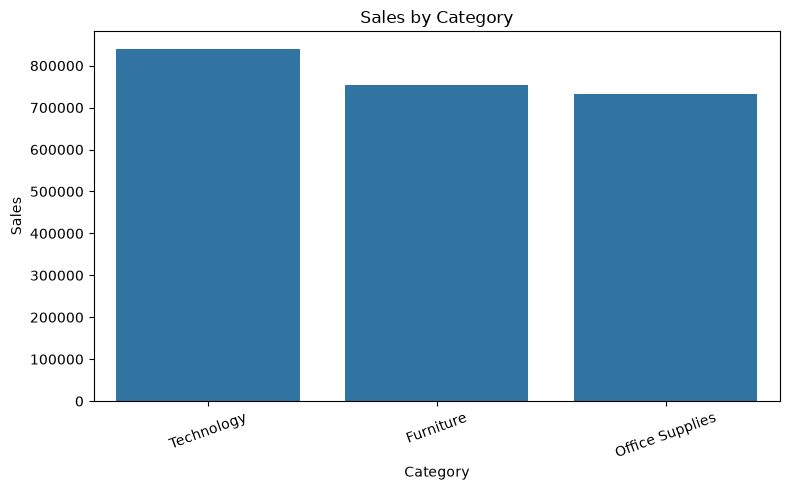

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_analysis,
    x="Category",
    y="Sales"
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

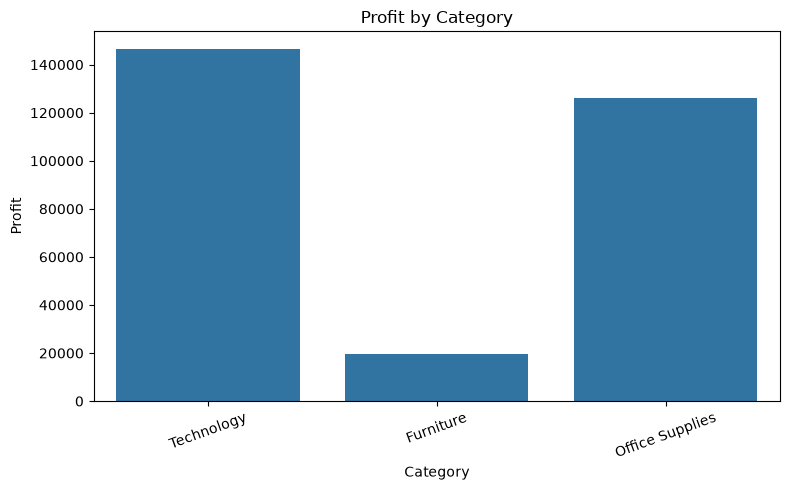

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_analysis,
    x="Category",
    y="Profit"
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

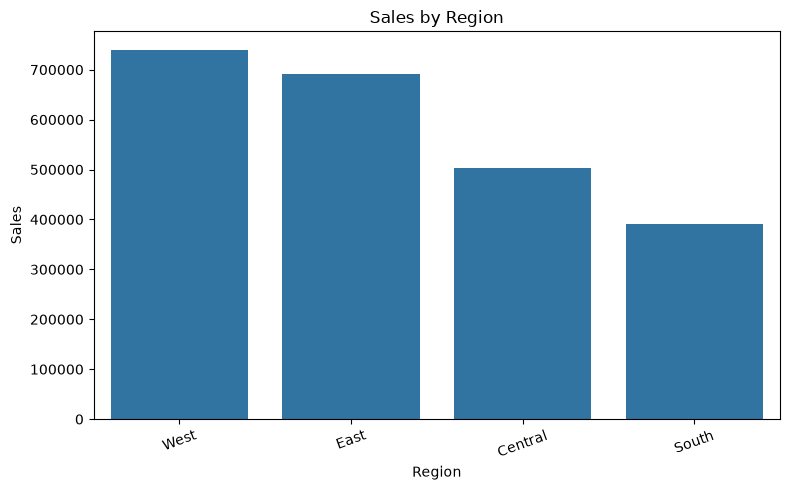

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=region_analysis,
    x="Region",
    y="Sales"
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

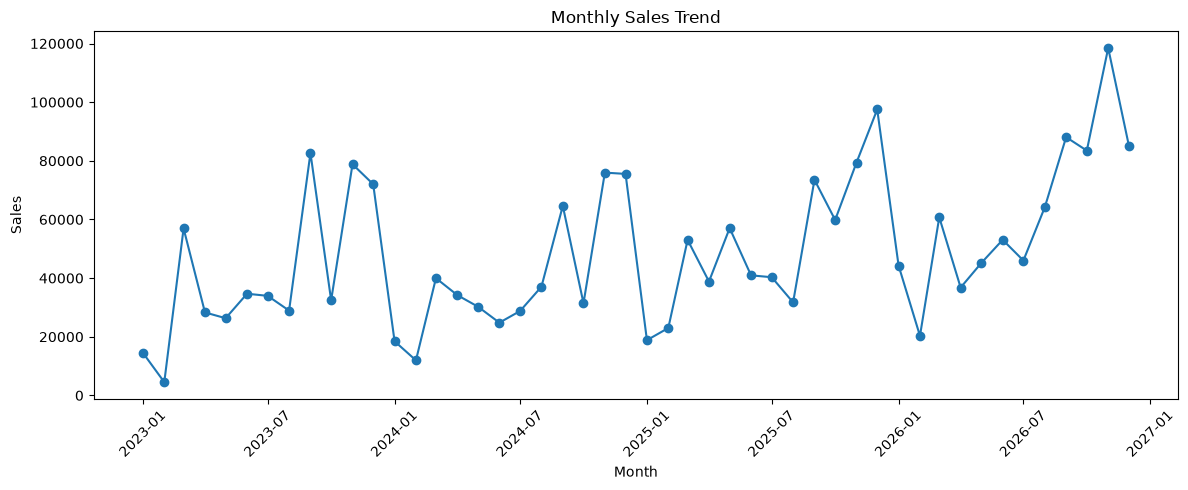

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis["Year Month"],
    monthly_analysis["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

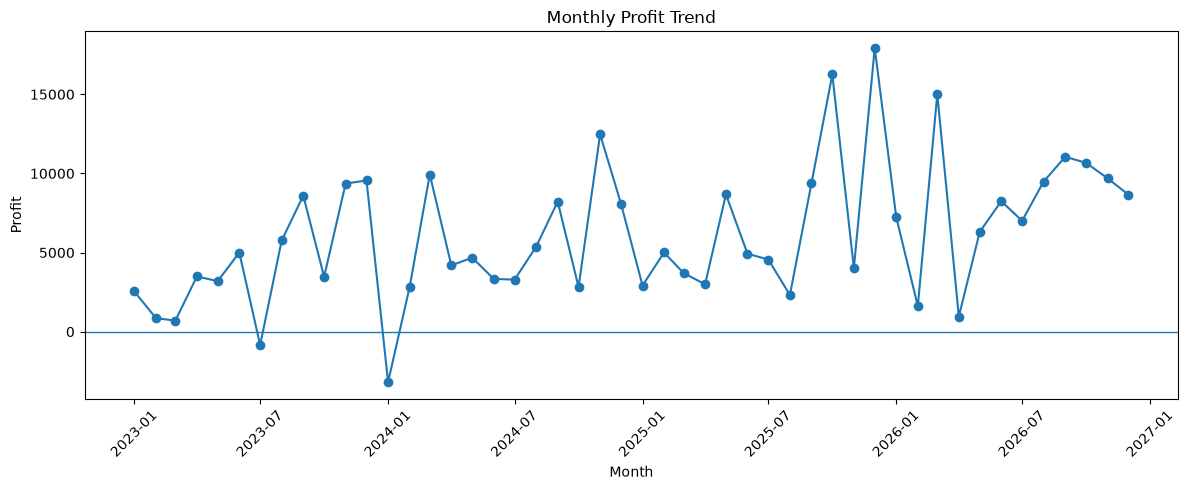

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis["Year Month"],
    monthly_analysis["Profit"],
    marker="o"
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
avg_order_value = total_sales / total_orders if total_orders else 0
avg_order_lines = len(sales_df) / total_orders if total_orders else 0

print("OVERALL BUSINESS METRICS")
print("=" * 60)
print(f"Total Sales:       ${total_sales:,.2f}")
print(f"Total Profit:      ${total_profit:,.2f}")
print(f"Profit Margin:     {profit_margin:.2f}%")
print(f"Total Orders:      {total_orders:,}")
print(f"Total Customers:   {total_customers:,}")
print(f"Total Quantity:    {total_quantity:,}")
print(f"Average Order Value: ${avg_order_value:,.2f}")
print(f"Average Order Lines: {avg_order_lines:.2f}")

OVERALL BUSINESS METRICS
Total Sales:       $2,326,534.35
Total Profit:      $292,296.81
Profit Margin:     12.56%
Total Orders:      5,111
Total Customers:   804
Total Quantity:    38,654
Average Order Value: $455.20
Average Order Lines: 1.99


In [33]:
best_category = category_analysis.loc[
    category_analysis["Profit"].idxmax()
]

print("BEST CATEGORY BY PROFIT")
print("=" * 60)
print(f"Category: {best_category['Category']}")
print(f"Sales: ${best_category['Sales']:,.2f}")
print(f"Profit: ${best_category['Profit']:,.2f}")
print(f"Margin: {best_category['Profit Margin']:.2f}%")

BEST CATEGORY BY PROFIT
Category: Technology
Sales: $839,893.28
Profit: $146,543.38
Margin: 17.45%


In [34]:
best_region = region_analysis.loc[
    region_analysis["Profit"].idxmax()
]

print("BEST REGION BY PROFIT")
print("=" * 60)
print(f"Region: {best_region['Region']}")
print(f"Sales: ${best_region['Sales']:,.2f}")
print(f"Profit: ${best_region['Profit']:,.2f}")
print(f"Margin: {best_region['Profit Margin']:.2f}%")

BEST REGION BY PROFIT
Region: West
Sales: $739,813.61
Profit: $110,798.82
Margin: 14.98%


In [35]:
best_subcategory = subcategory_analysis.loc[
    subcategory_analysis["Profit"].idxmax()
]

print("BEST SUBCATEGORY BY PROFIT")
print("=" * 60)
print(f"Sub-Category: {best_subcategory['Sub-Category']}")
print(f"Sales: ${best_subcategory['Sales']:,.2f}")
print(f"Profit: ${best_subcategory['Profit']:,.2f}")
print(f"Margin: {best_subcategory['Profit Margin']:.2f}%")

BEST SUBCATEGORY BY PROFIT
Sub-Category: Copiers
Sales: $150,745.29
Profit: $56,093.94
Margin: 37.21%


In [36]:
best_product = product_analysis.loc[
    product_analysis["Profit"].idxmax()
]

print("MOST PROFITABLE PRODUCT")
print("=" * 60)
print(f"Product: {best_product['Product Name']}")
print(f"Sales: ${best_product['Sales']:,.2f}")
print(f"Profit: ${best_product['Profit']:,.2f}")
print(f"Margin: {best_product['Profit Margin']:.2f}%")

MOST PROFITABLE PRODUCT
Product: Canon imageCLASS 2200 Advanced Copier
Sales: $61,599.82
Profit: $25,199.93
Margin: 40.91%


In [37]:
worst_product = product_analysis.loc[
    product_analysis["Profit"].idxmin()
]

print("BIGGEST LOSS-MAKING PRODUCT")
print("=" * 60)
print(f"Product: {worst_product['Product Name']}")
print(f"Sales: ${worst_product['Sales']:,.2f}")
print(f"Profit: ${worst_product['Profit']:,.2f}")
print(f"Margin: {worst_product['Profit Margin']:.2f}%")
print(f"Average Discount: {worst_product['Avg_Discount']:.2%}")

BIGGEST LOSS-MAKING PRODUCT
Product: Cubify CubeX 3D Printer Double Head Print
Sales: $11,099.96
Profit: $-8,879.97
Margin: -80.00%
Average Discount: 53.33%


In [38]:
highest_sales_month = monthly_analysis.loc[
    monthly_analysis["Sales"].idxmax()
]

print("HIGHEST SALES MONTH")
print("=" * 60)
print(
    f"Month: {highest_sales_month['Year Month'].strftime('%B %Y')}"
)
print(f"Sales: ${highest_sales_month['Sales']:,.2f}")
print(f"Profit: ${highest_sales_month['Profit']:,.2f}")

HIGHEST SALES MONTH
Month: November 2026
Sales: $118,454.51
Profit: $9,692.10


In [39]:
highest_profit_month = monthly_analysis.loc[
    monthly_analysis["Profit"].idxmax()
]

print("HIGHEST PROFIT MONTH")
print("=" * 60)
print(
    f"Month: {highest_profit_month['Year Month'].strftime('%B %Y')}"
)
print(f"Profit: ${highest_profit_month['Profit']:,.2f}")
print(f"Sales: ${highest_profit_month['Sales']:,.2f}")

HIGHEST PROFIT MONTH
Month: December 2025
Profit: $17,926.30
Sales: $97,502.28


In [40]:
lowest_profit_month = monthly_analysis.loc[
    monthly_analysis["Profit"].idxmin()
]

print("LOWEST PROFIT MONTH")
print("=" * 60)
print(
    f"Month: {lowest_profit_month['Year Month'].strftime('%B %Y')}"
)
print(f"Profit: ${lowest_profit_month['Profit']:,.2f}")
print(f"Sales: ${lowest_profit_month['Sales']:,.2f}")

LOWEST PROFIT MONTH
Month: January 2024
Profit: $-3,189.80
Sales: $18,461.92


In [41]:
print("KEY BUSINESS INSIGHTS")
print("=" * 60)

print(
    f"1. {best_category['Category']} is the most profitable category "
    f"with ${best_category['Profit']:,.2f} profit."
)

print(
    f"2. {best_region['Region']} is the most profitable region "
    f"with ${best_region['Profit']:,.2f} profit."
)

print(
    f"3. {best_subcategory['Sub-Category']} is the most profitable "
    f"subcategory with ${best_subcategory['Profit']:,.2f} profit."
)

print(
    f"4. {best_product['Product Name']} is the most profitable "
    f"product with ${best_product['Profit']:,.2f} profit."
)

print(
    f"5. {worst_product['Product Name']} is the biggest "
    f"loss-making product with ${worst_product['Profit']:,.2f} loss."
)

print(
    f"6. Overall business profit margin is {profit_margin:.2f}%."
)

print(
    "7. Discount and profitability show an observed association; "
    "this does not by itself establish causation."
)

KEY BUSINESS INSIGHTS
1. Technology is the most profitable category with $146,543.38 profit.
2. West is the most profitable region with $110,798.82 profit.
3. Copiers is the most profitable subcategory with $56,093.94 profit.
4. Canon imageCLASS 2200 Advanced Copier is the most profitable product with $25,199.93 profit.
5. Cubify CubeX 3D Printer Double Head Print is the biggest loss-making product with $-8,879.97 loss.
6. Overall business profit margin is 12.56%.
7. Discount and profitability show an observed association; this does not by itself establish causation.


In [42]:
print("DASHBOARD SETUP")
print("=" * 60)

print("Dashboard folder:", DASHBOARD_DIR)
print("App path:", APP_PATH)

DASHBOARD_DIR.mkdir(exist_ok=True)

print("Dashboard folder is ready.")

DASHBOARD SETUP
Dashboard folder: c:\Users\User\OneDrive\Pictures\Desktop\Shanmukha\Projects\Sales-Intelligence-Analytics\dashboard
App path: c:\Users\User\OneDrive\Pictures\Desktop\Shanmukha\Projects\Sales-Intelligence-Analytics\dashboard\app.py
Dashboard folder is ready.


In [43]:
app_code = r'''
import sqlite3
from pathlib import Path

import pandas as pd
import plotly.express as px
import streamlit as st


# =========================================================
# PAGE CONFIGURATION
# =========================================================

st.set_page_config(
    page_title="Sales Intelligence Dashboard",
    page_icon="📊",
    layout="wide"
)


# =========================================================
# DATABASE PATH
# =========================================================

PROJECT_ROOT = Path(__file__).resolve().parent.parent
DB_PATH = PROJECT_ROOT / "data" / "sales_intelligence.db"


# =========================================================
# DATABASE FUNCTION
# =========================================================

@st.cache_data
def run_query(query):
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(query, conn)


# =========================================================
# LOAD DATA
# =========================================================

sales_df = run_query("""
SELECT *
FROM sales
""")


# =========================================================
# PAGE TITLE
# =========================================================

st.title("📊 Sales Intelligence Dashboard")

st.markdown(
    "Interactive analysis of sales, profit, customers, products, "
    "regions and business performance."
)


# =========================================================
# SIDEBAR FILTERS
# =========================================================

st.sidebar.header("🔎 Dashboard Filters")

category_options = ["All"] + sorted(
    sales_df["Category"].dropna().unique().tolist()
)

region_options = ["All"] + sorted(
    sales_df["Region"].dropna().unique().tolist()
)

segment_options = ["All"] + sorted(
    sales_df["Segment"].dropna().unique().tolist()
)

ship_mode_options = ["All"] + sorted(
    sales_df["Ship Mode"].dropna().unique().tolist()
)

selected_category = st.sidebar.selectbox(
    "Category",
    category_options
)

selected_region = st.sidebar.selectbox(
    "Region",
    region_options
)

selected_segment = st.sidebar.selectbox(
    "Segment",
    segment_options
)

selected_ship_mode = st.sidebar.selectbox(
    "Ship Mode",
    ship_mode_options
)


# =========================================================
# APPLY FILTERS
# =========================================================

filtered_df = sales_df.copy()

if selected_category != "All":
    filtered_df = filtered_df[
        filtered_df["Category"] == selected_category
    ]

if selected_region != "All":
    filtered_df = filtered_df[
        filtered_df["Region"] == selected_region
    ]

if selected_segment != "All":
    filtered_df = filtered_df[
        filtered_df["Segment"] == selected_segment
    ]

if selected_ship_mode != "All":
    filtered_df = filtered_df[
        filtered_df["Ship Mode"] == selected_ship_mode
    ]


# =========================================================
# KPI CALCULATIONS
# =========================================================

total_sales = filtered_df["Sales"].sum()
total_profit = filtered_df["Profit"].sum()
total_quantity = filtered_df["Quantity"].sum()
total_orders = filtered_df["Order ID"].nunique()
total_customers = filtered_df["Customer ID"].nunique()

profit_margin = (
    total_profit / total_sales * 100
    if total_sales != 0
    else 0
)

average_order_value = (
    total_sales / total_orders
    if total_orders != 0
    else 0
)


# =========================================================
# KPI CARDS
# =========================================================

st.subheader("📌 Key Performance Indicators")

kpi1, kpi2, kpi3, kpi4, kpi5 = st.columns(5)

with kpi1:
    st.metric(
        "Total Sales",
        f"${total_sales:,.2f}"
    )

with kpi2:
    st.metric(
        "Total Profit",
        f"${total_profit:,.2f}"
    )

with kpi3:
    st.metric(
        "Profit Margin",
        f"{profit_margin:.2f}%"
    )

with kpi4:
    st.metric(
        "Orders",
        f"{total_orders:,}"
    )

with kpi5:
    st.metric(
        "Customers",
        f"{total_customers:,}"
    )


# =========================================================
# SECONDARY METRICS
# =========================================================

st.subheader("📈 Additional Metrics")

m1, m2 = st.columns(2)

with m1:
    st.metric(
        "Total Quantity",
        f"{total_quantity:,}"
    )

with m2:
    st.metric(
        "Average Order Value",
        f"${average_order_value:,.2f}"
    )


# =========================================================
# DATE PREPARATION
# =========================================================

filtered_df["Order Date"] = pd.to_datetime(
    filtered_df["Order Date"],
    errors="coerce"
)

filtered_df["Year Month"] = (
    filtered_df["Order Date"]
    .dt.to_period("M")
    .astype(str)
)


# =========================================================
# MONTHLY ANALYSIS
# =========================================================

monthly_data = (
    filtered_df
    .groupby("Year Month", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

monthly_data["Year Month"] = pd.to_datetime(
    monthly_data["Year Month"]
)

monthly_data = monthly_data.sort_values(
    "Year Month"
)


# =========================================================
# MONTHLY SALES TREND
# =========================================================

st.subheader("📅 Monthly Sales Trend")

fig_monthly_sales = px.line(
    monthly_data,
    x="Year Month",
    y="Sales",
    markers=True,
    title="Monthly Sales"
)

fig_monthly_sales.update_layout(
    xaxis_title="Month",
    yaxis_title="Sales"
)

st.plotly_chart(
    fig_monthly_sales,
    width="stretch"
)


# =========================================================
# CATEGORY & REGION
# =========================================================

col1, col2 = st.columns(2)

with col1:

    category_data = (
        filtered_df
        .groupby("Category", as_index=False)
        .agg(
            Sales=("Sales", "sum"),
            Profit=("Profit", "sum")
        )
    )

    fig_category = px.bar(
        category_data,
        x="Category",
        y="Sales",
        title="Sales by Category"
    )

    st.plotly_chart(
        fig_category,
        width="stretch"
    )


with col2:

    region_data = (
        filtered_df
        .groupby("Region", as_index=False)
        .agg(
            Sales=("Sales", "sum"),
            Profit=("Profit", "sum")
        )
    )

    fig_region = px.bar(
        region_data,
        x="Region",
        y="Sales",
        title="Sales by Region"
    )

    st.plotly_chart(
        fig_region,
        width="stretch"
    )


# =========================================================
# PROFIT ANALYSIS
# =========================================================

st.subheader("💰 Profit Analysis")

profit_data = (
    filtered_df
    .groupby("Sub-Category", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .sort_values("Profit", ascending=False)
)

fig_profit = px.bar(
    profit_data,
    x="Sub-Category",
    y="Profit",
    title="Profit by Sub-Category"
)

st.plotly_chart(
    fig_profit,
    width="stretch"
)


# =========================================================
# TOP PRODUCTS
# =========================================================

st.subheader("🏆 Top Products by Profit")

product_data = (
    filtered_df
    .groupby(
        ["Product ID", "Product Name"],
        as_index=False
    )
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .sort_values(
        "Profit",
        ascending=False
    )
    .head(10)
)

fig_products = px.bar(
    product_data.sort_values("Profit"),
    x="Profit",
    y="Product Name",
    orientation="h",
    title="Top 10 Products by Profit"
)

st.plotly_chart(
    fig_products,
    width="stretch"
)


# =========================================================
# DATA TABLE
# =========================================================

st.subheader("📋 Filtered Sales Data")

st.dataframe(
    filtered_df,
    width="stretch",
    hide_index=True
)


# =========================================================
# DOWNLOAD
# =========================================================

csv_data = filtered_df.to_csv(index=False)

st.download_button(
    label="⬇️ Download Filtered Data",
    data=csv_data,
    file_name="filtered_sales_data.csv",
    mime="text/csv"
)


# =========================================================
# BUSINESS INSIGHTS
# =========================================================

st.subheader("💡 Business Insights")

if not filtered_df.empty:

    best_category = (
        filtered_df
        .groupby("Category")["Profit"]
        .sum()
        .idxmax()
    )

    best_region = (
        filtered_df
        .groupby("Region")["Profit"]
        .sum()
        .idxmax()
    )

    best_product_row = (
        filtered_df
        .groupby("Product Name")["Profit"]
        .sum()
        .idxmax()
    )

    worst_product_row = (
        filtered_df
        .groupby("Product Name")["Profit"]
        .sum()
        .idxmin()
    )

    st.write(
        f"• **Most profitable category:** {best_category}"
    )

    st.write(
        f"• **Most profitable region:** {best_region}"
    )

    st.write(
        f"• **Most profitable product:** {best_product_row}"
    )

    st.write(
        f"• **Biggest loss-making product:** {worst_product_row}"
    )

else:

    st.warning(
        "No data available for the selected filters."
    )
'''

print("Dashboard code created successfully.")
print("Characters:", len(app_code))

Dashboard code created successfully.
Characters: 9627


In [44]:
APP_PATH.write_text(
    app_code,
    encoding="utf-8"
)

print("app.py created successfully.")
print("Location:", APP_PATH)

app.py created successfully.
Location: c:\Users\User\OneDrive\Pictures\Desktop\Shanmukha\Projects\Sales-Intelligence-Analytics\dashboard\app.py


In [45]:
print("APP FILE CHECK")
print("=" * 60)

print("Exists:", APP_PATH.exists())
print("Size:", APP_PATH.stat().st_size, "bytes")

APP FILE CHECK
Exists: True
Size: 10149 bytes


In [46]:
app_preview = APP_PATH.read_text(
    encoding="utf-8"
)

print(app_preview[:2000])


import sqlite3
from pathlib import Path

import pandas as pd
import plotly.express as px
import streamlit as st


# =========================================================
# PAGE CONFIGURATION
# =========================================================

st.set_page_config(
    page_title="Sales Intelligence Dashboard",
    page_icon="📊",
    layout="wide"
)


# =========================================================
# DATABASE PATH
# =========================================================

PROJECT_ROOT = Path(__file__).resolve().parent.parent
DB_PATH = PROJECT_ROOT / "data" / "sales_intelligence.db"


# =========================================================
# DATABASE FUNCTION
# =========================================================

@st.cache_data
def run_query(query):
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(query, conn)


# =========================================================
# LOAD DATA
# =========================================

In [47]:
required_sections = [
    "st.set_page_config",
    "run_query",
    "Dashboard Filters",
    "KPI",
    "Monthly Sales Trend",
    "Sales by Category",
    "Sales by Region",
    "Top Products by Profit",
    "Download Filtered Data",
    "Business Insights"
]

print("DASHBOARD SECTION CHECK")
print("=" * 60)

for section in required_sections:
    print(
        f"{section}:",
        "FOUND" if section in app_code else "MISSING"
    )

DASHBOARD SECTION CHECK
st.set_page_config: FOUND
run_query: FOUND
Dashboard Filters: FOUND
KPI: FOUND
Monthly Sales Trend: FOUND
Sales by Category: FOUND
Sales by Region: FOUND
Top Products by Profit: FOUND
Download Filtered Data: FOUND
Business Insights: FOUND


In [48]:
import ast

try:
    ast.parse(app_code)
    print("Python syntax check: PASSED")
except SyntaxError as e:
    print("Python syntax check: FAILED")
    print(e)

Python syntax check: PASSED


In [49]:
print("DATABASE PATH USED BY DASHBOARD")
print("=" * 60)
print(DB_PATH)

print("Database exists:", DB_PATH.exists())

DATABASE PATH USED BY DASHBOARD
c:\Users\User\OneDrive\Pictures\Desktop\Shanmukha\Projects\Sales-Intelligence-Analytics\data\sales_intelligence.db
Database exists: True


In [50]:
print("FINAL DASHBOARD FILE")
print("=" * 60)
print(APP_PATH)

if APP_PATH.exists():
    print("Ready to run with Streamlit.")
else:
    print("app.py was not created.")

FINAL DASHBOARD FILE
c:\Users\User\OneDrive\Pictures\Desktop\Shanmukha\Projects\Sales-Intelligence-Analytics\dashboard\app.py
Ready to run with Streamlit.


In [51]:
print("SALES INTELLIGENCE DASHBOARD SETUP COMPLETE")
print("=" * 60)
print("Notebook analysis: READY")
print("Database: READY")
print("Dashboard app.py: READY")
print()
print("Next step: run the Streamlit dashboard from the terminal.")

SALES INTELLIGENCE DASHBOARD SETUP COMPLETE
Notebook analysis: READY
Database: READY
Dashboard app.py: READY

Next step: run the Streamlit dashboard from the terminal.
